# **Procesamiento y limpieza de datos**

En este notebook preprocesamos los datos. Para ello limpiaremos la columna Titulo_Semantico y extraeremos información útil.

In [31]:
import pandas as pd

df = pd.read_csv("dataset_boe_universidades.csv")
df.head()

,ID_Disposicion,Fecha_Publicacion,Titulo_Semantico,Año_Semana,Año,Bloque_3dias
0,BOE-A-1995-26,1995-01-02,"Resolución de 30 de noviembre de 1994, de la U...",1995-01,1995,0
1,BOE-A-1995-27,1995-01-02,"Resolución de 12 de diciembre de 1994, de la U...",1995-01,1995,0
2,BOE-A-1995-77,1995-01-03,"Resolución de 28 de noviembre de 1994, de la U...",1995-01,1995,0
3,BOE-A-1995-78,1995-01-03,"Resolución de 13 de diciembre de 1994, de la U...",1995-01,1995,0
4,BOE-A-1995-205,1995-01-03,"Resolución de 12 de diciembre de 1994, de la U...",1995-01,1995,0


## **Análisis de datos faltantes**

In [32]:
df.isna().sum()

,0
ID_Disposicion,0
Fecha_Publicacion,0
Titulo_Semantico,2
Año_Semana,0
Año,0
Bloque_3dias,0


Eliminamos las filas que tengan valores faltantes porque al ser solo 2 no afecta a nuestro dataset.

In [33]:
df.dropna(inplace=True)

## **Limpieza de texto**

Ahora, quitamos las tildes, eliminamos los caracteres no alfabéticos, como los números y quitamos los espacios dobles. Además, creamos dos columnas, una con los datos manteniendo las mayúsculas y otro en minúsculas. Esto lo hacemos porque hay muchos nombres propios como nombres de universidades, nombres de personas o lugares que queremos conservar como entidades.

In [34]:
import re
import unicodedata

def limpiar_texto_boe(texto):
    # Quitar tildes, pero conservar mayúsculas/minúsculas
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto)
                    if unicodedata.category(c) != 'Mn')
    # Eliminar caracteres no alfabéticos (mantiene espacios)
    texto = re.sub(r'[^A-Za-zÑñÁÉÍÓÚÜáéíóúü\s]', ' ', texto)
    # Compactar espacios
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


df['texto_limpio'] = df['Titulo_Semantico'].apply(limpiar_texto_boe)


df['texto_lower'] = df['texto_limpio'].str.lower()


## **Formato de fechas**

Cambiamos la columna fecha_publicacion a formato datetime y obtenemos una columna con el año, mes y trimestre.

In [37]:
df['Fecha_Publicacion'] = pd.to_datetime(df['Fecha_Publicacion'])
df['Mes'] = df['Fecha_Publicacion'].dt.month
df['Trimestre'] = df['Fecha_Publicacion'].dt.to_period('Q')

Creamos bloques de 3 días que van de lunes a miércoles y de jueves a domingo. Así tenemos una medida temporal con suficientes datos para hacer análisis temporales con sentido. Además, los domingos no hay disposiciones.

In [44]:
import pandas as pd

# Tomar la primera fecha del dataset como inicio
inicio = df['Fecha_Publicacion'].min()

# Función para asignar bloque progresivo (lunes-miércoles, jueves-domingo)
def asignar_bloque_temporal(fecha):
    dias = (fecha - inicio).days
    ciclo = dias // 7
    dia_en_ciclo = dias % 7
    # 0 = lunes, 6 = domingo relativo al inicio
    if dia_en_ciclo <= 2:   # lunes-miércoles
        bloque = ciclo * 2
    else:                   # jueves-domingo
        bloque = ciclo * 2 + 1
    return bloque

df['Bloque_3dias'] = df['Fecha_Publicacion'].apply(asignar_bloque_temporal)


Como vemos en la gráfica a penas hay bloques de 3 días con ninguna disposición. Esto es algo positivo para el posterior análisis temporal.

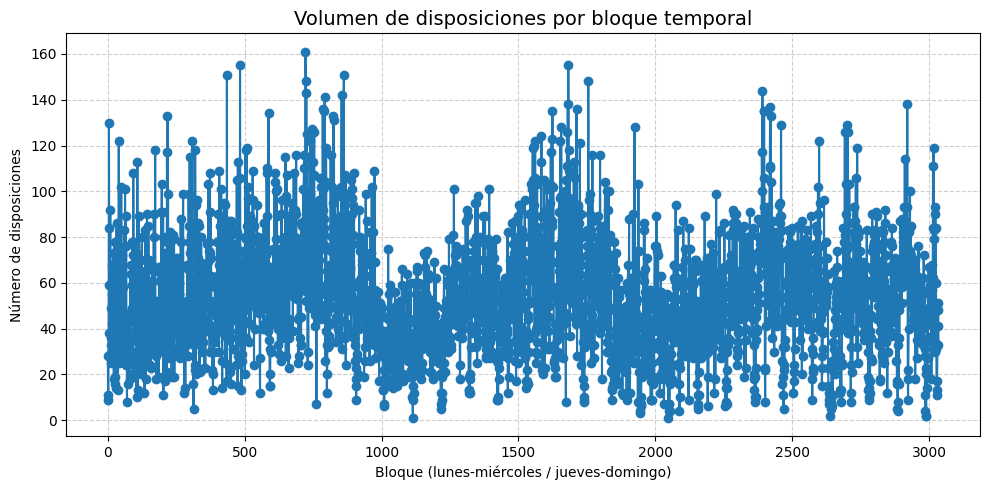

In [45]:
import matplotlib.pyplot as plt

# Contar número de títulos por bloque
conteo_bloques = df.groupby('Bloque_3dias')['ID_Disposicion'].count()

plt.figure(figsize=(10, 5))
plt.plot(conteo_bloques.index, conteo_bloques.values, marker='o')
plt.title('Volumen de disposiciones por bloque temporal', fontsize=14)
plt.xlabel('Bloque (lunes-miércoles / jueves-domingo)')
plt.ylabel('Número de disposiciones')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Análisis por día de la semana

In [39]:
# Crear columna con el nombre del día de la semana
# Lunes=0 ... Domingo=6
df['Dia_semana_num'] = df['Fecha_Publicacion'].dt.dayofweek
df['Dia_semana'] = df['Fecha_Publicacion'].dt.day_name()

# Agrupar por día de la semana
conteo_dias = df.groupby('Dia_semana_num').size().reset_index(name='n_disposiciones')

dias_orden = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
conteo_dias['Dia_semana'] = [dias_orden[i] for i in conteo_dias['Dia_semana_num']]
conteo_dias = conteo_dias.sort_values('Dia_semana_num').reset_index(drop=True)

conteo_dias

,Dia_semana_num,n_disposiciones,Dia_semana
0,0,27638,Lunes
1,1,29543,Martes
2,2,26261,Miércoles
3,3,29161,Jueves
4,4,25937,Viernes
5,5,24034,Sábado


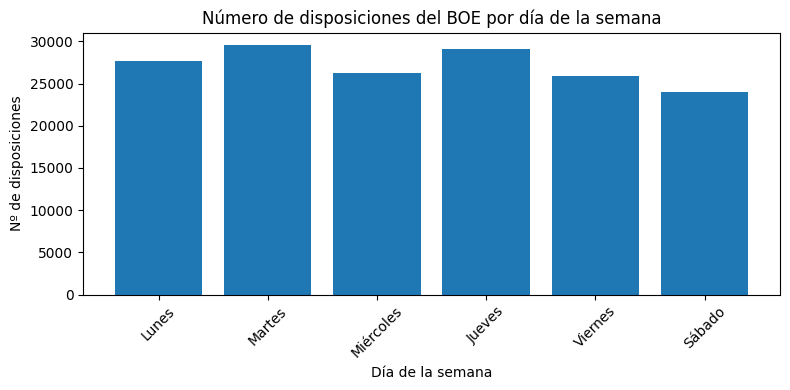

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(conteo_dias['Dia_semana'], conteo_dias['n_disposiciones'])
plt.title('Número de disposiciones del BOE por día de la semana')
plt.ylabel('Nº de disposiciones')
plt.xlabel('Día de la semana')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Longitud de disposiciones**

Contamos la longitud de las disposiciones para ver la evolución de esta a lo largo del tiempo.

In [41]:
# Crear columna con longitud (en número de palabras o caracteres)
df['longitud_titulo'] = df['Titulo_Semantico'].str.split().str.len()  # nº de palabras

# Calcular longitud media
longitud_media = df['longitud_titulo'].mean()
print(f"Longitud media de los títulos: {longitud_media:.2f} palabras")


Longitud media de los títulos: 30.01 palabras


En la gráfica vemos que cada año el tamaño de las disposiciones va disminuyendo.

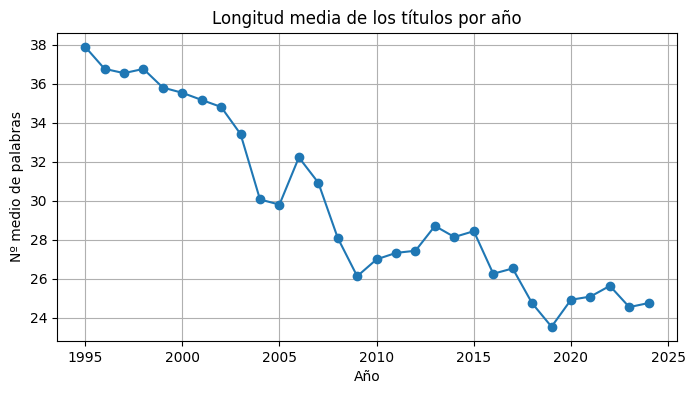

In [42]:
longitud_por_año = df.groupby('Año')['longitud_titulo'].mean().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(longitud_por_año['Año'], longitud_por_año['longitud_titulo'], marker='o')
plt.title('Longitud media de los títulos por año')
plt.ylabel('Nº medio de palabras')
plt.xlabel('Año')
plt.grid(True)
plt.show()


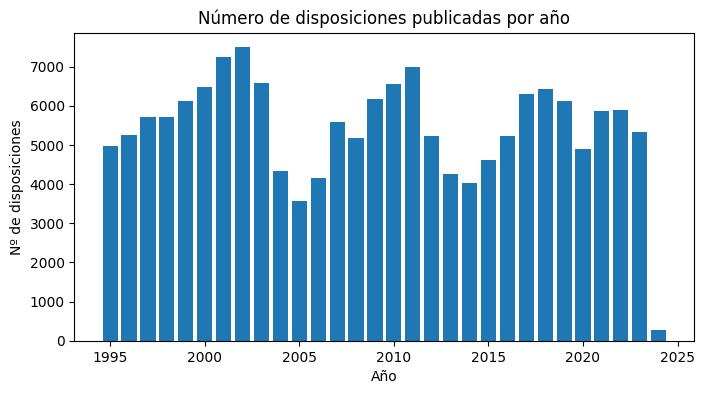

In [43]:
conteo_anual = df.groupby('Año').size().reset_index(name='n_disposiciones')

plt.figure(figsize=(8,4))
plt.bar(conteo_anual['Año'], conteo_anual['n_disposiciones'])
plt.title('Número de disposiciones publicadas por año')
plt.ylabel('Nº de disposiciones')
plt.xlabel('Año')
plt.show()


In [47]:
df.head()

,ID_Disposicion,Fecha_Publicacion,Titulo_Semantico,Año_Semana,Año,Bloque_3dias,texto_limpio,texto_lower,Mes,Trimestre,Bloques_dias_semana,Dia_semana_num,Dia_semana,longitud_titulo
0,BOE-A-1995-26,1995-01-02,"Resolución de 30 de noviembre de 1994, de la U...",1995-01,1995,0,Resolucion de de noviembre de de la Universida...,resolucion de de noviembre de de la universida...,1,1995Q1,0,0,Monday,30
1,BOE-A-1995-27,1995-01-02,"Resolución de 12 de diciembre de 1994, de la U...",1995-01,1995,0,Resolucion de de diciembre de de la Universida...,resolucion de de diciembre de de la universida...,1,1995Q1,0,0,Monday,42
2,BOE-A-1995-77,1995-01-03,"Resolución de 28 de noviembre de 1994, de la U...",1995-01,1995,0,Resolucion de de noviembre de de la Universida...,resolucion de de noviembre de de la universida...,1,1995Q1,0,1,Tuesday,48
3,BOE-A-1995-78,1995-01-03,"Resolución de 13 de diciembre de 1994, de la U...",1995-01,1995,0,Resolucion de de diciembre de de la Universida...,resolucion de de diciembre de de la universida...,1,1995Q1,0,1,Tuesday,40
4,BOE-A-1995-205,1995-01-03,"Resolución de 12 de diciembre de 1994, de la U...",1995-01,1995,0,Resolucion de de diciembre de de la Universida...,resolucion de de diciembre de de la universida...,1,1995Q1,0,1,Tuesday,45


In [46]:
df.to_csv("dataset_universidades_procesado.csv", index=False, encoding='utf-8')